# Tugas Besar 2 IF3170 Intelegensi Artifisial - Kel. 16 LimaSerangkAI


Group Number: 16

Group Members:
- Muhammad Aufa Farabi (13523023)
- Joel Hotlan Haris Siahaan (13523025)
- Julius Arthur (13523030)
- Ferdinand Gabe Tua Sinaga (13523051)
- Muhammad Iqbal Haidar (13523111)

## Import Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.metrics import accuracy_score
from cvxopt import matrix, solvers

## Import Dataset

In [53]:
# Example of reading a csv file from a gdrive link
df = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')
# Take the file id from the gdrive file url
# https://drive.google.com/file/d/1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU/view?usp=sharing => The file id is 1ZUtiaty9RPXhpz5F2Sy3dFPHF4YIt5iU
# and then put it in this format:
# https://drive.google.com/uc?id={file_id}
# Don't forget to change the access to public

# Exploratory Data Analysis

In [54]:
df.head(10)

,Student_ID,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,3743,1,17,1,9670,1,1,118.0,1,19,...,0,6,6,6,14.000000,0,12.4,0.5,1.79,Graduate
1,3540,1,1,1,9070,1,1,139.0,1,1,...,0,6,7,6,12.166667,1,16.2,0.3,-0.92,Graduate
2,1118,1,1,1,9500,1,1,138.0,1,38,...,0,8,8,7,13.571429,0,13.9,-0.3,0.79,Graduate
3,791,1,17,1,9773,1,1,138.0,1,1,...,0,6,6,6,13.833333,0,11.1,0.6,2.02,Graduate
4,4381,1,7,1,9500,1,2,140.0,1,38,...,0,8,14,4,11.325000,1,12.7,3.7,-1.70,Dropout
5,877,1,17,1,9070,1,1,119.0,1,38,...,0,6,7,5,11.000000,0,15.5,2.8,-4.06,Dropout
6,4090,2,43,1,8014,0,14,133.1,1,34,...,2,7,15,1,13.000000,1,9.4,-0.8,-3.12,Dropout
7,3329,5,39,1,9119,1,1,120.0,1,37,...,0,5,10,2,11.000000,0,9.4,-0.8,-3.12,Enrolled
8,461,1,1,1,9130,1,1,160.0,1,3,...,0,5,5,5,14.600000,0,12.7,3.7,-1.70,Graduate
9,1834,1,1,1,9147,1,1,133.1,1,19,...,0,5,10,3,12.285714,0,10.8,1.4,1.74,Dropout


In [55]:
df.isna().sum()

Student_ID                                        0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [56]:
df.duplicated().sum()

np.int64(0)

In [57]:
df["Mother's qualification"].unique()

array([19,  1, 38, 34, 37,  3,  4,  2,  6, 12, 26, 39, 40,  9,  5, 14, 43,
       10, 41, 11, 35, 30, 36, 42, 18, 29, 44, 22])

In [58]:
df["Course"].value_counts()

Course
9500    523
9147    266
9238    255
9085    240
9773    234
9670    192
9991    184
9254    172
171     159
9070    157
9003    152
8014    143
9853    142
9119    114
9130    100
9556     54
33        9
Name: count, dtype: int64

/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


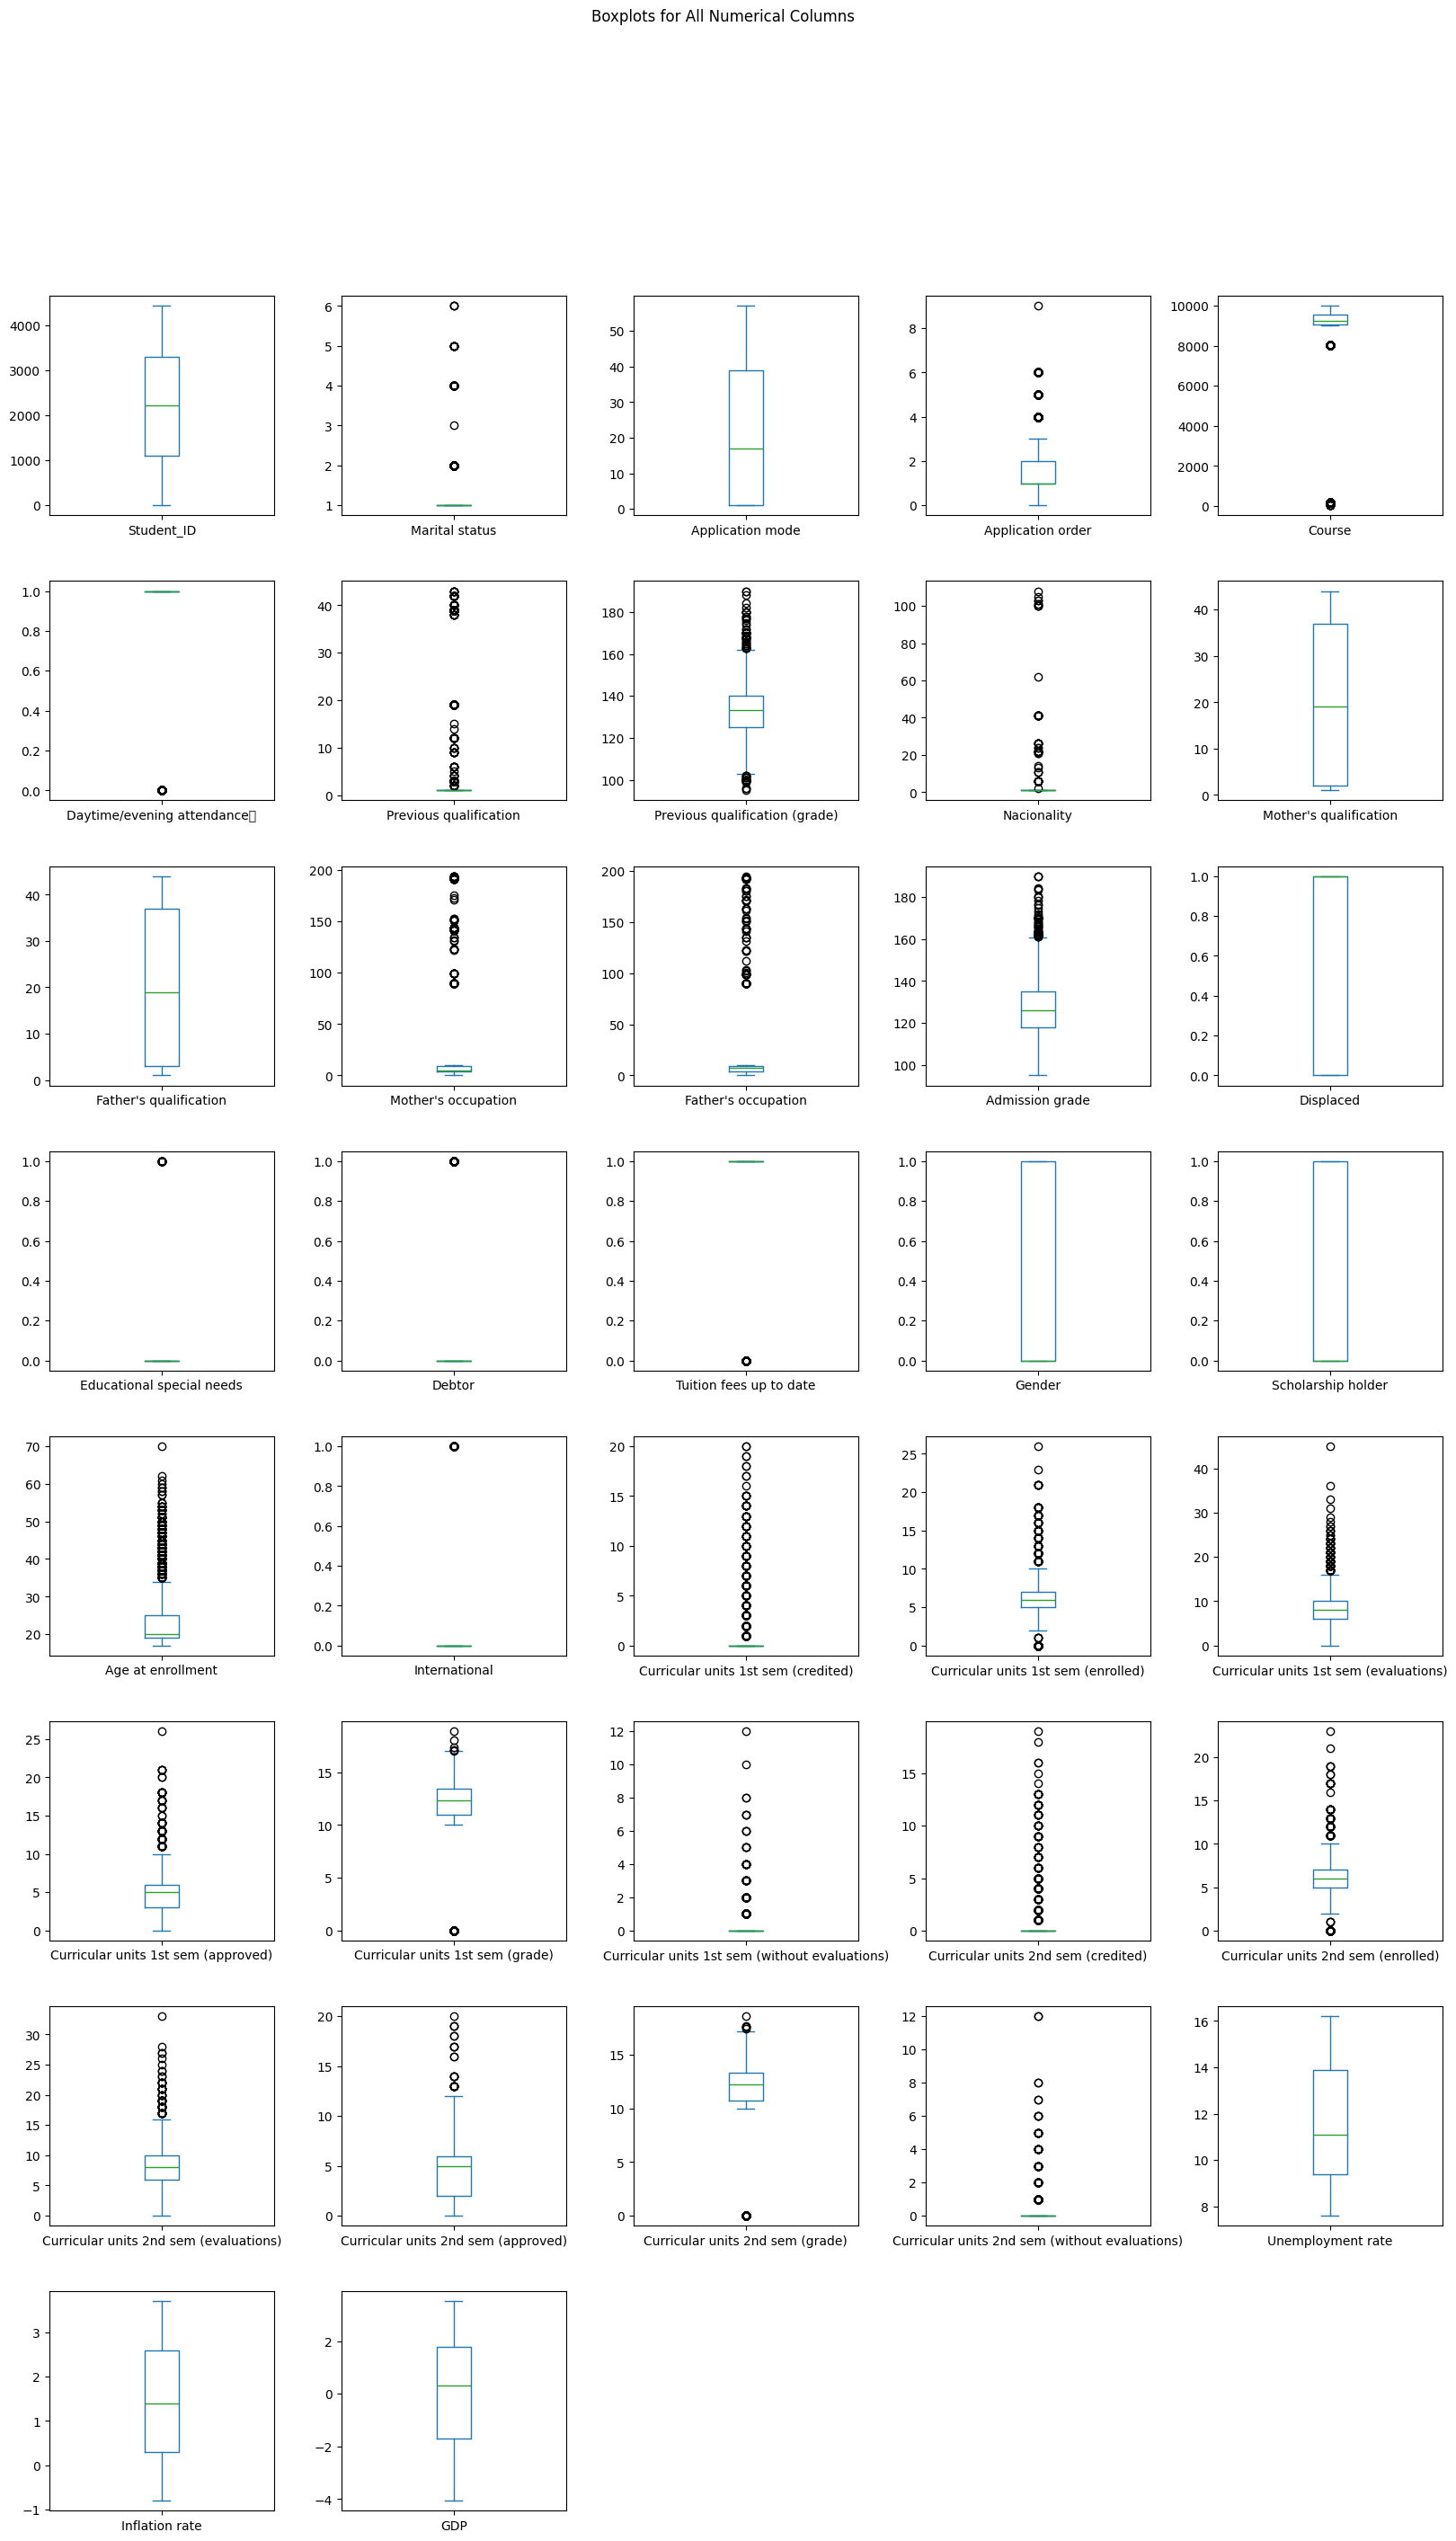

In [59]:
numerical_cols = df.select_dtypes(include=['number']).columns
n_cols = len(numerical_cols)
cols_per_row = 5
n_rows = (n_cols + cols_per_row - 1) // cols_per_row

ax = df[numerical_cols].plot(
    kind='box',
    subplots=True,
    layout=(n_rows, cols_per_row),
    figsize=(4 * cols_per_row, 4 * n_rows),
    sharey=False,
    title='Boxplots for All Numerical Columns'
)


plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

In [60]:
impossible_units = df[df['Curricular units 1st sem (enrolled)'] < 0]
print(f"Impossible curricular units found: {len(impossible_units)}")

Impossible curricular units found: 0


# 1. Split Training Set and Validation Set

In [61]:
train_set, val_set = train_test_split(df, test_size=0.33, random_state=42, stratify=df['Target'])

In [62]:
y_train = train_set['Target']
y_val = val_set['Target']

In [63]:
x_train = train_set.drop('Target', axis=1)
x_val = val_set.drop('Target', axis=1)

# 2. Data Cleaning and Preprocessing

## A. Data Cleaning

### I. Handling Missing Data

In [64]:
num_cols = [
    'Student_ID', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]

cat_cols = [
    'Marital status', 'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance\t', 'Previous qualification', 'Nacionality',
    'Mother\'s qualification', 'Father\'s qualification', 'Mother\'s occupation',
    'Father\'s occupation', 'Displaced', 'Educational special needs', 'Debtor',
    'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]


num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

preprocess = ColumnTransformer(transformers=[
    ('num', num_imputer, num_cols),
    ('cat', cat_imputer, cat_cols)
])

train_imputed = preprocess.fit_transform(train_set)
val_imputed = preprocess.transform(val_set)
test_imputed = preprocess.transform(df_test)

train_set = pd.DataFrame(train_imputed, columns=list(num_cols)+list(cat_cols))
val_set = pd.DataFrame(val_imputed, columns=list(num_cols)+list(cat_cols))
test_set = pd.DataFrame(test_imputed, columns=list(num_cols)+list(cat_cols))

df.head()

,Student_ID,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,3743,1,17,1,9670,1,1,118.0,1,19,...,0,6,6,6,14.000000,0,12.4,0.5,1.79,Graduate
1,3540,1,1,1,9070,1,1,139.0,1,1,...,0,6,7,6,12.166667,1,16.2,0.3,-0.92,Graduate
2,1118,1,1,1,9500,1,1,138.0,1,38,...,0,8,8,7,13.571429,0,13.9,-0.3,0.79,Graduate
3,791,1,17,1,9773,1,1,138.0,1,1,...,0,6,6,6,13.833333,0,11.1,0.6,2.02,Graduate
4,4381,1,7,1,9500,1,2,140.0,1,38,...,0,8,14,4,11.325000,1,12.7,3.7,-1.70,Dropout


Data kosong pada kolom numerikal diisi dengan median pada kolom tersebut. Hal ini dilakukan karena terdapat *skewed data* seperti pada kolom grade. Sedangkan, data kosong pada kolom kategorikal diisi dengan data modus pada kolom tersebut.

### II. Dealing with Outliers

Pada data ini, tidak ada outlier yang perlu ditangani. Nilai "outlier" pada setiap kolom merupakan nilai alami yang dapat terjadi di kehidupan nyata. Nilai yang sangat rendah maupun tinggi pada kolom grade, yang masih dalam rentang valid, merupakan nilai memang dapat diraih oleh setiap siswa. Hal yang sama terjadi pada seluruh kolom lainnya.


### III. Remove Duplicates

In [65]:
'''
data duplikat sebaiknya dihapus dengan menyisakan satu data unik saja.
Hal ini dilakukan agar model tidak terpengaruh dengan data duplikat.
'''
train_set = train_set.drop_duplicates(keep='first')
val_set = val_set.drop_duplicates(keep='first')
test_set = test_set.drop_duplicates(keep='first')

In [66]:
train_set

,Student_ID,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),...,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International
0,712.0,100.0,160.0,45.0,0.0,5.0,5.0,0.0,0.000000,0.0,...,37.0,9.0,8.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,26.0,151.0,157.0,18.0,0.0,6.0,8.0,5.0,11.600000,0.0,...,38.0,9.0,9.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,3728.0,125.0,125.0,20.0,0.0,6.0,8.0,4.0,14.250000,0.0,...,1.0,9.0,7.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3,4010.0,114.0,109.5,19.0,0.0,5.0,5.0,0.0,0.000000,0.0,...,1.0,5.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,2130.0,182.0,156.8,18.0,0.0,6.0,6.0,6.0,12.666667,0.0,...,1.0,5.0,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2069,1913.0,125.0,116.3,18.0,0.0,7.0,8.0,7.0,13.428571,0.0,...,1.0,9.0,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2070,1196.0,125.0,128.5,18.0,0.0,7.0,9.0,6.0,11.500000,0.0,...,19.0,4.0,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2071,2498.0,110.0,108.7,43.0,0.0,6.0,6.0,6.0,13.000000,0.0,...,1.0,9.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2072,3079.0,129.0,118.2,19.0,0.0,5.0,5.0,5.0,10.800000,0.0,...,37.0,4.0,9.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


Tidak ada data duplikat yang ditemukan

### IV. Feature Engineering

In [67]:
def engineering_logic(df_in):
    df_out = df_in.copy()
    # if 'Student_ID' in df_in.columns:
    #     df_out = df_out.drop('Student_ID', axis=1)
    skewed_cols = ["Curricular units 1st sem (evaluations)", "Curricular units 2nd sem (evaluations)"]
    for col in skewed_cols:
        if col in df_out.columns:
            df_out[col] = np.log1p(df_out[col])

# Average_grade menunjukan performa murid secara keseluruhan waktu

    if "Curricular units 1st sem (grade)" in df_out.columns:
        df_out["Average_grade"] = (df_out["Curricular units 1st sem (grade)"] + df_out["Curricular units 2nd sem (grade)"]) / 2



  # Fitur ini menunjukkan banyaknya sks yang diambil dan disetujui pada seluruh semester
    df_out["Total_credits_approved"] = df_out["Curricular units 1st sem (approved)"] + df_out["Curricular units 2nd sem (approved)"]
    df_out["Total_credits_enrolled"] = df_out["Curricular units 1st sem (enrolled)"] + df_out["Curricular units 2nd sem (enrolled)"]

    def safe_rate(approved, enrolled):
      rate = approved / np.where(enrolled == 0, np.nan, enrolled)
      return np.nan_to_num(rate, nan=0)
#Menunjukkan berapa kredit yang berhasil
    df_out["Approval_Rate"] = safe_rate(df_out["Total_credits_approved"], df_out["Total_credits_enrolled"])
    return df_out

Melakukan feature engineering berupa transformasi logaritma pada fitur yang skewed serta membuat fitur turunan baru berupa **Approval_Rate** untuk menangkap pola rasio kelulusan SKS mahasiswa, **Average_grade** untuk menunjukan performa murid secara keseluruhan waktu. Tujuannya adalah untuk menormalkan distribusi data yang skewed dan menciptakan fitur baru yang lebih relevan untuk training model.

## B. Data Preprocessing


### I. Feature Scaling

In [68]:
class FeatureScaler(BaseEstimator, TransformerMixin):
  def __init__(self, cols) -> None:
    self.cols = cols
    self.scaler = StandardScaler()

  def fit(self, X, y=None):
    self.scaler.fit(X[self.cols])
    self.is_fitted_ = True
    return self

  def transform(self, X):
    X_copy = X.copy()
    X_copy[self.cols] = self.scaler.transform(X[self.cols])
    return X_copy

Scaling data menggunakan StandardScaler dan RobustScaler (bagian bawah pada setiap section algoritma). Alasan melakukannya karena algoritma Logistic Regression dan SVM sensitif terhadap skala data, sehingga diperlukan scaling agar tidak terjadi dominansi fitur dan untuk mempercepat algoritma mencapai konvergen.

### II. Feature Encoding

In [69]:
class FeatureEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols
        self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

    def fit(self, X, y=None):
        self.encoder.fit(X[self.cols])
        self.is_fitted_ = True
        return self

    def transform(self, X):
        X_copy = X.copy()

        encoded_data = self.encoder.transform(X_copy[self.cols])

        feature_names = self.encoder.get_feature_names_out(self.cols)
        encoded_df = pd.DataFrame(encoded_data, columns=feature_names, index=X_copy.index)

        X_copy = X_copy.drop(columns=self.cols)
        X_final = pd.concat([X_copy, encoded_df], axis=1)

        return X_final

class TargetFeatureEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols, smoothing=0):
        self.cols = cols
        self.smoothing = smoothing
        self.maps = {}
        self.global_mean = None

    def fit(self, X, y=None):
        if y is None:
            raise ValueError("Target y is required for Target Encoding fit method.")

        self.global_mean = np.mean(y)

        temp_df = X[self.cols].copy()
        temp_df['target'] = y.values if hasattr(y, 'values') else y

        for col in self.cols:
            stats = temp_df.groupby(col)['target'].agg(['count', 'mean'])
            counts = stats['count']
            means = stats['mean']

            smooth = (counts * means + self.smoothing * self.global_mean) / (counts + self.smoothing)

            self.maps[col] = smooth

        return self

    def transform(self, X):
        X_copy = X.copy()

        for col in self.cols:
            if col in self.maps:
                X_copy[col] = X_copy[col].map(self.maps[col])

                X_copy[col] = X_copy[col].fillna(self.global_mean)

        return X_copy

Encoding data menggunakan kombinasi OneHotEncoder untuk fitur kardinalitas rendah dan TargetFeatureEncoder untuk fitur kardinalitas tinggi. TargetFeatureEncoder mengubah data kategorikal menjadi nilai rata-rata dari variabel target untuk kategori tersebut. Alasan penggunaannya adalah karena Logistic Regression dan SVM membutuhkan fitur bertipe numerikal untuk melatih model dan melakukan prediksi.

### III. Handling Imbalanced Dataset

**(Dilakukan di bawah, pada setiap section algoritma)** Penanganan imbalanced data menggunakan SMOTE. Alasan dilakukan ini adalah untuk menyeimbangkan jumlah sampel data training untuk setiap kelas target supaya model tidak bias terhadap kelas mayoritas.

### IV. Data Normalization

Tidak dilakukan Normalisasi Data pada preprocessing

### V. Dimensionality Reduction

**(Dilakukan di bawah, pada setiap section algoritma)** Feature Selection menggunakan SelectKBest dengan pemilihan 5 fitur yang paling berpengaruh terhadap nilai target. Alasan melakukan ini untuk meningkatkan efisiensi komputasi saat proses training dan mengurangi fitur yang kemungkinan besar hanya berupa noise.

# 3. Compile Preprocessing Pipeline

In [70]:
X = df.drop('Target', axis=1)
y = df['Target']

# Dropout/Enrolled/Graduate -> 0/1/2
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Classes:", le.classes_)
print("X Shape:", X.shape)
print("y Shape:", y_encoded.shape)

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder, FunctionTransformer
high_card_cols = ['Course', "Mother's occupation", "Father's occupation"]
low_card_cols = ['Marital status', 'Application mode', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']
num_cols = [c for c in X.select_dtypes(include=['number']).columns if c not in high_card_cols + low_card_cols]

preprocessor = ColumnTransformer(transformers=[
    ('target_enc', TargetFeatureEncoder(cols=high_card_cols, smoothing=10), high_card_cols),

    ('one_hot', FeatureEncoder(cols=low_card_cols), low_card_cols),

    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ]), num_cols),

    ('categorical', Pipeline([
        ('imputer_cat', SimpleImputer(strategy='most_frequent')),
        ('scaler', RobustScaler())
    ]), num_cols)
])

Classes: ['Dropout' 'Enrolled' 'Graduate']
X Shape: (3096, 37)
y Shape: (3096,)


In [71]:
class SaveToCSV(BaseEstimator, TransformerMixin):
    def __init__(self, filename="output.csv"):
        self.filename = filename

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Save X to CSV
        df = pd.DataFrame(X)
        df.to_csv(self.filename, index=False)

        return X


# 4. Modeling and Validation

## A. DTL

In [72]:
import numpy as np
import pickle

class TreeNode:
    def __init__(self, is_leaf, classification = None, attribute = None, threshold = None, branches = None, len_instances = 0):
        self.is_leaf = is_leaf
        self.classification = classification
        self.attribute = attribute
        self.threshold = threshold
        self.branches = branches if branches is not None else {}
        self.len_instances = len_instances

class Rule:
    def __init__(self, conditions, classification, accuracy=0.0, y_val_covered=0):
        self.conditions = conditions # list (attribute, operator, value)
        self.classification = classification
        self.accuracy = accuracy
        self.y_val_covered = y_val_covered #instance dari dataset validasi

    # cek instance validasi masuk ke dalam rule
    def is_matched(self, instance):
        for attribute, operator, value in self.conditions:
            # atribut numerikal -> value merupakan threshold
            if operator == '<=' and instance[attribute] > value:
                return False
            elif operator == '>' and instance[attribute] <= value:
                return False
            elif operator == '==' and instance[attribute] != value: # atribut kategorikal
                return False
        return True

    # def formatted_string(self):
    #     cond_str = " AND ".join([f"X[{a}] {op} {v}" for a, op, v in self.conditions])
    #     return f"IF {cond_str} THEN {self.classification} (acc={self.accuracy:.3f}, cov={self.coverage})"


class DecisionTreeLearning:
    def __init__(self, max_depth=None, min_samples_split=2, min_samples_leaf=1, pruning='none'):
        self.tree = None
        self.classes = None
        self.default_class = None
        self.pruning = pruning
        self.n_features = 0
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.rules = [] # Buat rule post pruning


    # Hitung entropy dari examples
    def calculate_entropy(self, examples):
        y = examples[:, -1]
        if len(y) == 0:
            return 0

        # Ambil jumlah class dari examples
        unique_classes, counts = np.unique(y, return_counts=True)

        entropy = 0
        for count in counts:
            probability = count / len(y)
            if probability > 0:
                entropy -= probability * np.log2(probability)

        return entropy

    # hitung information gain pada atribut tertentu
    def calculate_information_gain(self, examples, attribute, threshold):
        X_a = examples[:, attribute]
        parent_entropy = self.calculate_entropy(examples)

        len_S = len(examples)
        weighted_entropy = 0

        # Perhtitungan dari split threshold untuk atribut numerik
        if threshold is not None:
            left_indices = X_a <= threshold
            right_indices = X_a > threshold
            left_subset, right_subset  = examples[left_indices], examples[right_indices]

            weight_left = len(left_subset) / len_S
            weight_right = len(right_subset) / len_S

            weighted_entropy += (weight_left * self.calculate_entropy(left_subset) +
                                    weight_right * self.calculate_entropy(right_subset))
        else:
            # Ambil nilai unik pada atribut
            unique_values = np.unique(X_a)
            for value in unique_values:
                # ambil index untuk nilai atribut yg cocok sama value
                indices = np.where(X_a == value)[0]
                subset = examples[indices]

                weight = len(subset) / len_S
                weighted_entropy += weight * self.calculate_entropy(subset)

        information_gain = parent_entropy - weighted_entropy
        return information_gain

    # Hitung split information dari atribut tertentu
    def calculate_split_information(self, examples, attribute, threshold):
        X_a = examples[:, attribute]
        len_S = len(examples)
        split_info = 0

        # Pecah atribut numerik jadi diskrit berdasarkan threshold
        if threshold is not None:
            len_S_left = np.sum(X_a <= threshold)
            len_S_right = np.sum(X_a > threshold)

            proportion_left = len_S_left / len_S
            proportion_right = len_S_right / len_S

            if proportion_left > 0:
                split_info -= proportion_left * np.log2(proportion_left)
            if proportion_right > 0:
                split_info -= proportion_right * np.log2(proportion_right)

        else:
            unique_values = np.unique(X_a)
            for value in unique_values:
                len_Si = np.sum(X_a == value)
                proportion = len_Si / len_S
                if proportion > 0:
                    split_info -= proportion * np.log2(proportion)

        return split_info

    # Hitung gain ratio buat atribut tertentu
    def calculate_gain_ratio(self, examples, attribute, threshold = None):

        info_gain = self.calculate_information_gain(examples, attribute, threshold)
        split_info = self.calculate_split_information(examples, attribute, threshold)

        if split_info == 0:
            return 0

        gain_ratio = info_gain / split_info

        return gain_ratio

    # Cari threshold terbaik dari beberapa kandidat threshold (numerik)
    def find_best_threshold(self, examples, attribute):
        # index atribut yang udah terurut buat valuenya
        X_a = examples[:, attribute]
        y = examples[:, -1]

        sorted_indices = np.argsort(X_a)
        X_sorted = X_a[sorted_indices]
        y_sorted = y[sorted_indices]

        threshold_candidates = []
        for i in range(len(X_sorted) - 1):
            # Ambil threshold dari midway dua nilai yang berbeda kelasnya
            if y_sorted[i] != y_sorted[i + 1]:
                threshold = (X_sorted[i] + X_sorted[i + 1]) / 2
                threshold_candidates.append(threshold)

        if (len(threshold_candidates) == 0):
            return None, 0

        best_threshold = None
        best_gain_ratio = -9999999

        # Cari threshold terbaik berdasarkan gain ratio (C4.5)
        for threshold in threshold_candidates:
           gain_ratio = self.calculate_gain_ratio(examples, attribute,  threshold)
           if gain_ratio > best_gain_ratio:
               best_gain_ratio = gain_ratio
               best_threshold = threshold

        return best_threshold, best_gain_ratio

    # Cari kelas paling banyak dari examples
    def plurality_value(self, examples):
        y = examples[:, -1]

        unique_classes, counts = np.unique(y, return_counts=True)
        most_common_class = unique_classes[np.argmax(counts)]
        return most_common_class

    def importance(self, attribute, examples):
        X = examples[:, :-1]
        y = examples[:, -1]

        X_a = X[:, attribute]

        # Cek apakah atribut numerik atau kategorik
        if np.issubdtype(X_a.dtype, np.number):
            threshold, gain_ratio = self.find_best_threshold(examples, attribute)
        else:
            threshold = None
            gain_ratio = self.calculate_gain_ratio(examples, attribute, threshold=None)

        return gain_ratio, threshold

    def argmax_importance(self, examples, attributes):
        best_attribute = None
        best_threshold = None
        best_gain_ratio = -9999999

        for attribute in attributes:
            gain_ratio, threshold = self.importance(attribute, examples)

            if gain_ratio > best_gain_ratio:
                best_gain_ratio = gain_ratio
                best_attribute = attribute
                best_threshold = threshold

        return best_attribute, best_threshold

    def build_decision_tree(self, examples, attributes, parent_examples, depth=0):
        # Base case
        # Examples kosong
        if len(examples) == 0:
            most_common_class = self.plurality_value(parent_examples)
            return TreeNode(is_leaf=True, classification=most_common_class)

        # Kondisi stop untuk max depth atau min_samples_split
        if (self.max_depth is not None and depth >= self.max_depth) or (len(examples) < self.min_samples_split):
            most_common_class = self.plurality_value(examples)
            return TreeNode(is_leaf=True, classification=most_common_class, len_instances=len(examples))


        # Semua examples punya klasifikasi sama
        if len(np.unique(examples[:, -1])) == 1:
            exs_classification = examples[0, -1]
            return TreeNode(is_leaf=True, classification=exs_classification, len_instances = len(examples))

        # Attribute empty
        if len(attributes) == 0:
            most_allcommon_class = self.plurality_value(examples)
            return TreeNode(is_leaf=True, classification=most_allcommon_class, len_instances = len(examples))

        # Recursive case
        best_attribute, best_threshold = self.argmax_importance(examples, attributes)
        remaining_attributes = attributes - {best_attribute}

        tree = TreeNode(is_leaf=False, attribute=best_attribute, threshold=best_threshold, len_instances = len(examples))

        # Buat dua branches (<=, > dari threshold) untuk atribut numerik
        if best_threshold is not None:
            left_indices = examples[:, best_attribute] <= best_threshold
            right_indices = examples[:, best_attribute] > best_threshold
            left_subset_examples = examples[left_indices]
            right_subset_examples = examples[right_indices]

            if len(left_subset_examples) < self.min_samples_leaf or len(right_subset_examples) < self.min_samples_leaf:
                most_common_class = self.plurality_value(examples)
                return TreeNode(is_leaf=True, classification=most_common_class, len_instances=len(examples))

            left_subtree = self.build_decision_tree(left_subset_examples, remaining_attributes, parent_examples = examples, depth=depth + 1)
            right_subtree = self.build_decision_tree(right_subset_examples, remaining_attributes, parent_examples = examples, depth=depth + 1)

            tree.branches['<='] = left_subtree
            tree.branches['>'] = right_subtree

        # Buat branch dari tree sebanyak nilai unik atribut kategorik
        else:
            X = examples[:, :-1]
            unique_values = np.unique(X[:, best_attribute])

            # bikin value dan subset dalam dictionary
            value_subsets = {}
            is_split_valid = True

            for value in unique_values:
                indices = np.where(X[:, best_attribute] == value)[0]
                subset_examples = examples[indices]

                if len(subset_examples) < self.min_samples_leaf:
                    is_split_valid = False
                    break

                # Simpan value dan subset_examples sebagai tuple
                value_subsets[value] = subset_examples

            # Jika split ga valid, jadikan leaf
            if not is_split_valid:
                most_common_class = self.plurality_value(examples)
                return TreeNode(is_leaf=True, classification=most_common_class, len_instances=len(examples))

            for value, subset_examples in value_subsets.items():
                subtree = self.build_decision_tree(subset_examples, remaining_attributes, parent_examples=examples, depth=depth + 1)
                tree.branches[value] = subtree

        return tree

    # convert tree jadi rules buat rule pruning
    def tree_to_rules(self, node, conditions=[]):
        # base case
        if node.is_leaf:
            rule = Rule(conditions=conditions.copy(), classification=node.classification)
            self.rules.append(rule)
            return

        # rekursif untuk atribut numerik
        if node.threshold is not None:
            if '<=' in node.branches:
                left_conditions = conditions + [(node.attribute, '<=', node.threshold)]
                self.tree_to_rules(node.branches['<='], left_conditions)
            if '>' in node.branches:
                right_conditions = conditions + [(node.attribute, '>', node.threshold)]
                self.tree_to_rules(node.branches['>'], right_conditions)

        else: # buat kategorikal
            for value, child in node.branches.items():
                new_conditions = conditions + [(node.attribute, '==', value)]
                self.tree_to_rules(child, new_conditions)


    def calculate_rule_accuracy(self, rule, examples):
        X = examples[:, :-1]
        y = examples[:, -1]

        y_covered = []
        for i in range(len(examples)):
            if rule.is_matched(X[i]):
                y_covered.append(y[i])

        if len(y_covered) == 0:
            return 0.0, 0

        # Hitung akurasi dataset validasi
        n_true = sum([1 for c in y_covered if c == rule.classification])
        accuracy = n_true / len(y_covered)
        return accuracy, len(y_covered)

    # Helper untuk proses pruning rule dengan remove preconditions nya
    def prune_rule(self, rule, val_examples):

        if len(rule.conditions) == 0:
            return rule

        best_rule = rule
        best_accuracy, best_y_covered = self.calculate_rule_accuracy(rule, val_examples)
        best_rule.accuracy = best_accuracy
        best_rule.y_val_covered = best_y_covered

        accuracy_improved = True
        while accuracy_improved and len(best_rule.conditions) > 0:
            accuracy_improved = False

            # Buat rule baru dengan menghapus condition secara greedy
            for i in range(len(best_rule.conditions)):
                # hapus condition i
                new_conditions = best_rule.conditions[:i] + best_rule.conditions[i+1:]
                new_rule = Rule(conditions=new_conditions, classification=best_rule.classification)

                accuracy, y_covered = self.calculate_rule_accuracy(new_rule, val_examples)

                if accuracy >= best_accuracy:
                    best_rule = new_rule
                    best_accuracy = accuracy
                    best_y_covered = y_covered
                    accuracy_improved = True  # tetap di dalam loop outer
                    break

        best_rule.accuracy = best_accuracy
        best_rule.y_val_covered = best_y_covered
        return best_rule

    # post pruning dengan rule
    def post_pruning_by_rule(self, val_examples):

        self.rules = []
        self.tree_to_rules(self.tree)

        pruned_rules = []
        for rule in self.rules:
            pruned_rule = self.prune_rule(rule, val_examples)
            pruned_rules.append(pruned_rule)

        # sort rule by accuracy
        accuracies = np.array([rule.accuracy for rule in pruned_rules])
        sorted_indices = np.argsort(accuracies)[::-1]
        pruned_rules = [pruned_rules[i] for i in sorted_indices]

        self.rules = pruned_rules


    # post pruning dengan reduced error
    def reduced_error_pruning(self, node, val_examples):
        if node.is_leaf:
            return node

        # Buat atribut numerik
        if node.threshold is not None:
            left_indices = val_examples[:, node.attribute] <= node.threshold
            right_indices = val_examples[:, node.attribute] > node.threshold

            # rekursif untuk <= threshold
            if '<=' in node.branches and np.sum(left_indices) > 0:
                node.branches['<='] = self.reduced_error_pruning(
                    node.branches['<='], val_examples[left_indices]
                )
            # rekursif untuk > threshold
            if '>' in node.branches and np.sum(right_indices) > 0:
                node.branches['>'] = self.reduced_error_pruning(
                    node.branches['>'], val_examples[right_indices]
                )
        else: # buat atribut kategorikal
            X = val_examples[:, :-1]
            for value, child in list(node.branches.items()):
                indices = np.where(X[:, node.attribute] == value)[0]
                # lakukan rekursif kalau example nya ga kosong
                if len(indices) > 0:
                    node.branches[value] = self.reduced_error_pruning(
                        child,
                        val_examples[indices]
                    )

        X_val = val_examples[:, :-1]
        y_val = val_examples[:, -1]

        # Hitung subtree accuracy dari kecocokan hasil prediksi dengan dataset validasi
        subtree_predictions = []
        for i in range(len(X_val)):
            prediction = self.predict_single_instance(X_val[i], node)
            subtree_predictions.append(prediction)
        subtree_accuracy = np.mean(np.array(subtree_predictions) == y_val)

        most_common = self.plurality_value(val_examples)
        leaf_accuracy = np.mean(y_val == most_common)

        # prune jika leaf accuracy >= subtree accuracy
        if leaf_accuracy >= subtree_accuracy:
            return TreeNode(is_leaf=True, classification=most_common, len_instances=len(val_examples))

        return node


    # Training model DTL dari training data
    def fit(self, X_train, y_train, X_val=None, y_val=None):
        X = np.array(X_train)
        y = np.array(y_train)

        self.classes = np.unique(y)
        n_features = X.shape[1]
        attributes = set(range(n_features))

        examples = np.column_stack((X, y))
        self.default_class = self.plurality_value(examples) # buat kasus unseen values di atribut

        self.tree = self.build_decision_tree(examples, attributes, parent_examples=None, depth=0)

        # Post pruning
        if self.pruning == 'rule':
            val_examples = np.column_stack((np.array(X_val), np.array(y_val)))
            self.post_pruning_by_rule(val_examples)
        elif self.pruning == 'reduced-error':
            val_examples = np.column_stack((np.array(X_val), np.array(y_val)))
            self.tree = self.reduced_error_pruning(self.tree, val_examples)

        return self

    # Predict satu instance dari dataset validasi berdasarkan model DTL
    def predict_single_instance(self, X_instance, node):

        if node.is_leaf:
            return node.classification

        attribute_value = X_instance[node.attribute]

        # atribut numerik
        if node.threshold is not None:
            if attribute_value <= node.threshold:
                return self.predict_single_instance(X_instance, node.branches['<='])
            else:
                return self.predict_single_instance(X_instance, node.branches['>'])

        # atribut kategorik
        else:
            if attribute_value in node.branches:
                return self.predict_single_instance(X_instance, node.branches[attribute_value])
            else:
                return self.default_class

    # Predict dataset validasi dengan DTL
    def predict(self, X_val):
        if self.tree is None:
            raise Exception("Model belum dilatih dengan fit().")

        arr_X = np.array(X_val)
        predictions = []

        if self.pruning == 'rule': # Untuk pruning by rule
            for i in range(len(arr_X)):
                prediction = self.default_class
                for rule in self.rules:
                    if rule.is_matched(arr_X[i]):
                        prediction = rule.classification
                        break
                predictions.append(prediction)

        else:
            for i in range(len(arr_X)):
                prediction = self.predict_single_instance(arr_X[i], self.tree)
                predictions.append(prediction)

        return np.array(predictions)

    # print Decision tree secara rekurisf
    def print_tree(self):
        if self.tree is None:
            raise Exception("Model belum dilatih dengan fit().")

        def print_node(node, depth):
            indent = "  " * depth
            if node.is_leaf:
                print(f"{indent}Leaf: Class = {node.classification} (len_instances = {node.len_instances})")
            else:
                if depth == 0:
                    prefix = "Root:"
                else:
                    prefix = "IntlNode:"

                print(f"{indent}{prefix} Attribute {node.attribute} (len_instances = {node.len_instances})")
                if node.threshold is not None:
                    print(f"{indent}  |->: <= {node.threshold}")
                    print_node(node.branches['<='], depth + 2)
                    print(f"{indent}  |->: > {node.threshold}")
                    print_node(node.branches['>'], depth + 2)
                else:
                    for value, subtree in node.branches.items():
                        print(f"{indent}  |->: value = {value}")
                        print_node(subtree, depth + 2)

        print_node(self.tree, 0)


    def save_model(self, file_path):
        model_data = {
            'tree': self.tree,
            'classes': self.classes,
            'default_class': self.default_class,
            'pruning': self.pruning,
            'max_depth': self.max_depth,
            'min_samples_split': self.min_samples_split,
            'min_samples_leaf': self.min_samples_leaf,
            'rules': self.rules
        }
        with open(file_path, 'wb') as file:
            pickle.dump(model_data, file)
        print(f"Model disimpan di {file_path}")

    def load_model(self, file_path):
        with open(file_path, 'rb') as file:
            model_data = pickle.load(file)

        self.tree = model_data['tree']
        self.classes = model_data['classes']
        self.default_class = model_data['default_class']
        self.pruning = model_data['pruning']
        self.max_depth = model_data['max_depth']
        self.min_samples_split = model_data['min_samples_split']
        self.min_samples_leaf = model_data['min_samples_leaf']
        self.rules = model_data['rules']

        print(f"Model berhasil di-load dari {file_path}")

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import numpy as np

param_grid = {
    "model__max_depth": [5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 3, 5]
}

best_score = -1
best_params = None

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for depth in param_grid["model__max_depth"]:
    for split in param_grid["model__min_samples_split"]:
        for leaf in param_grid["model__min_samples_leaf"]:

            scores = []

            for train_idx, val_idx in kf.split(x_train):
                X_train_cv = x_train.iloc[train_idx]
                y_train_cv = y_train_encoded[train_idx]
                X_val_cv = x_train.iloc[val_idx]
                y_val_cv = y_train_encoded[val_idx]

                pipeline = ImbPipeline([
                    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
                    ('preprocess', preprocessor),
                    ('smote', SMOTE(random_state=42)),
                    ('selection', SelectKBest(score_func=f_classif, k=5)),
                    ('model', DecisionTreeLearning(
                        max_depth=depth,
                        min_samples_split=split,
                        min_samples_leaf=leaf
                    ))
                ])

                pipeline.fit(X_train_cv, y_train_cv)
                y_pred = pipeline.predict(X_val_cv)
                acc = accuracy_score(y_val_cv, y_pred)
                scores.append(acc)

            mean_score = np.mean(scores)
            print(f"depth={depth}, split={split}, leaf={leaf} → acc={mean_score}")

            if mean_score > best_score:
                best_score = mean_score
                best_params = (depth, split, leaf)

print("\nBest Param:", best_params)
print("Best Score:", best_score)


In [73]:
from sklearn.feature_selection import SelectKBest, f_classif

model_pipeline_dtl = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)),
    ('model', DecisionTreeLearning(max_depth=5, min_samples_split=2, min_samples_leaf=5))
])


le = LabelEncoder()


y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# model_pipeline_dtl.fit(x_train, y_train_encoded, model__X_val = x_val, model__y_val = y_val_encoded)
model_pipeline_dtl.fit(x_train, y_train_encoded)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

y_pred = model_pipeline_dtl.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

# yang lebih bagus dari sklearn (Akurasi DTL Sklearn (C4.5): 0.7348336594911937)
# ('model', DecisionTreeLearning(max_depth=5, min_samples_split=10, min_samples_leaf=1)) Akurasi DTL: 0.735812133072407
# ('model', DecisionTreeLearning(max_depth=5, min_samples_split=5, min_samples_leaf=1)) Akurasi DTL: 0.735812133072407
# ('model', DecisionTreeLearning(max_depth=10, min_samples_split=5, min_samples_leaf=1)) Akurasi DTL: 0.735812133072407
print("\nAkurasi DTL:", acc)

# Save Model
model_pipeline_dtl.named_steps['model'].save_model('model_dtl.pkl')

Preprocessing Complete!
Processed Train Shape: (2074, 37)

Akurasi DTL: 0.6917808219178082
Model disimpan di model_dtl.pkl


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [74]:
# Cara Load Model

loaded_model = DecisionTreeLearning()
loaded_model.load_model('model_dtl.pkl')

print("Model loaded successfully!")

# Reconstruct the pipeline
loaded_pipeline = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor), # Ensure 'preprocessor' is the same object or re-fitted
    # Note: SMOTE is not needed for prediction, only training
    ('selection', SelectKBest(score_func=f_classif, k=5)), # Must match your training k
    ('model', loaded_model) # Insert your loaded model here
])

# IMPORTANT: You must re-fit the preprocessor/selector on the training data
loaded_pipeline.fit(x_train, y_train_encoded)

y_pred_new = loaded_pipeline.predict(df_test)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

y_pred = model_pipeline_dtl.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi DTL:", acc)

Model berhasil di-load dari model_dtl.pkl
Model loaded successfully!
Preprocessing Complete!
Processed Train Shape: (2074, 37)

Akurasi DTL: 0.6917808219178082


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [75]:
# from sklearn.metrics import accuracy_score
# model = DecisionTreeLearning()
# model.fit(X_train_processed, y_train_encoded)
# y_pred = model.predict(x_val)
# acc = accuracy_score(y_val, y_pred)
# print("\nAkurasi DTL (C4.5):", acc)

# rulePruningModel = DecisionTreeLearning(pruning='rule')
# rulePruningModel.fit(X_train_processed, y_train.values, X_val_processed, y_val)
# y_pred = rulePruningModel.predict(X_val_processed)
# acc = accuracy_score(y_val, y_pred)
# print("\nAkurasi DTL (C4.5) dengan Rule Pruning:", acc)

# reductionErrorPruningModel = DecisionTreeLearning(pruning='reduction-error')
# reductionErrorPruningModel.fit(X_train_processed, y_train.values, X_val_processed, y_val)
# y_pred = reductionErrorPruningModel.predict(X_val_processed)
# acc = accuracy_score(y_val, y_pred)
# print("\nAkurasi DTL (C4.5) dengan Reduction:", acc)

In [76]:
from sklearn.tree import DecisionTreeClassifier
DTLSklearnModel = DecisionTreeClassifier(criterion='entropy', ccp_alpha=0.2)
DTLSklearnModel.fit(x_train, y_train_encoded)
y_predSklearn = DTLSklearnModel.predict(x_val)
accSklearn = accuracy_score(y_val_encoded, y_pred)
print("\nAkurasi DTL Sklearn (C4.5):", accSklearn)


Akurasi DTL Sklearn (C4.5): 0.6917808219178082


## B. Logistic Regression

In [77]:
# Type your code here
class MinibatchGradientDescent:
    def __init__(self, lr=0.1, epochs=10, batch_size=32):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.epochs):
            idx = np.random.permutation(n_samples)
            X_shuffled = X[idx]
            y_shuffled = y[idx]

            for i in range(0, n_samples, self.batch_size):
                batch_end = min(i + self.batch_size, n_samples)
                X_batch = X_shuffled[i:batch_end]
                y_batch = y_shuffled[i:batch_end]

                linear_model = np.dot(X_batch, self.weights) + self.bias
                y_predicted = self.sigmoid(linear_model)

                error = y_batch - y_predicted

                self.weights += self.lr * np.dot(X_batch.T, error) / len(X_batch)
                self.bias += self.lr * np.mean(error)

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        pred = self.sigmoid(linear)
        return np.where(pred >= 0.5, 1, 0)

    def compute_loss(self, X, y):
        n_samples = X.shape[0]
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)

        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

In [78]:
import pickle

class LogisticRegressionOVO:
    def __init__(self, lr = 0.1, epochs = 10, batch_size=32):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.models = None
        self.n_classes = None
        self.label_to_idx = None
        self.idx_to_label = None

    def get_params(self, deep=True):
        params = {
            'lr': self.lr,
            'epochs': self.epochs,
            'batch_size': self.batch_size
        }
        return params

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

    def fit(self, X, y):
        unique_classes = np.unique(y)

        self.n_classes = len(unique_classes)
        self.label_to_idx = {label: idx for idx, label in enumerate(unique_classes)}
        self.idx_to_label = {idx: label for label, idx in self.label_to_idx.items()}

        y_numeric = np.array([self.label_to_idx[label] for label in y])

        if self.n_classes > 2 :
            self.models = {}
            for i in range (self.n_classes):
                for j in range (i + 1, self.n_classes):
                    mask = (y_numeric == i) | (y_numeric == j)
                    X_pair = X[mask]
                    y_pair = y_numeric[mask]

                    y_binary = (y_pair == i).astype(int)

                    model = MinibatchGradientDescent(lr=self.lr, epochs=self.epochs, batch_size=self.batch_size)
                    model.fit(X_pair, y_binary)

                    self.models[(i,j)] = model
        else :
            self.models = MinibatchGradientDescent(lr=self.lr, epochs=self.epochs, batch_size=self.batch_size)
            self.models.fit(X, y_numeric)

    def predict(self, X):
        if isinstance(self.models, dict):
            n_samples = X.shape[0]
            votes = np.zeros((n_samples, self.n_classes))

            for (i, j), model in self.models.items():
                predictions = model.predict(X)

                for idx in range(n_samples):
                    if predictions[idx] == 1:
                        votes[idx,i] += 1
                    else :
                        votes[idx, j] += 1
                # votes_i = (predictions >= 0.5).astype(int)

                # # Add votes vector-wise (faster than for-loop)
                # votes[:, i] += votes_i
                # votes[:, j] += (1 - votes_i)

            best_indices = np.argmax(votes, axis=1)
            y_pred = np.array([self.idx_to_label[idx] for idx in best_indices])

            return y_pred

        else :
            y_pred_numeric = self.models.predict(X)
            y_pred = np.array([self.idx_to_label[val] for val in y_pred_numeric])

            return y_pred

    def save_model(self, filepath):
        model_data = {
            'models': self.models,
            'n_classes': self.n_classes,
            'label_to_idx': self.label_to_idx,
            'idx_to_label': self.idx_to_label,
            'lr': self.lr,
            'epochs': self.epochs
        }

        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)

        print(f"Model berhasil disimpan ke {filepath}")

    def load_model(self, filepath):
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)

        self.models = model_data['models']
        self.n_classes = model_data['n_classes']
        self.label_to_idx = model_data['label_to_idx']
        self.idx_to_label = model_data['idx_to_label']
        self.lr = model_data['lr']
        self.epochs = model_data['epochs']

        print(f"Model berhasil di-load dari {filepath}")
        print(f"Jumlah kelas: {self.n_classes}")
        print(f"Jumlah model: {len(self.models)}")

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, KFold



params = {
    'batch_size': [16,32,64,128],
    'lr':[0.1, 0.5, 0.8],
    'epochs':[10,50,100]
}
for el in params['batch_size']:
  for el2 in params['lr']:
    for el3 in params['epochs']:
      kf = KFold(n_splits=5, shuffle = True, random_state = 42)
      log = LogisticRegressionOVO(lr=el2, epochs = el3, batch_size = el)
      scores = cross_val_score(log, x_train, y_train, cv=kf, scoring='f1_macro')
      print(f'batch_size: {el}')
      print(f' lr: {el2}')
      print(f' epochs: {el3}')
      print(f'scores:{scores}')



In [80]:
model_pipeline = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegressionOVO(lr=0.3, epochs=100, batch_size=32))
])

In [81]:
le = LabelEncoder()


y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

model_pipeline.fit(x_train, y_train_encoded)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

Preprocessing Complete!
Processed Train Shape: (2074, 37)


In [82]:

# modelLogRes = LogisticRegressionOVO(lr=0.8, epochs=10, batch_size=32)
# modelLogRes.fit(x_train_processed.to_numpy(), y_train_encoded)
# y_pred = modelLogRes.predict(x_val_processedto_numpy())
y_pred = model_pipeline.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi SGD OVO:", acc)

# Save Model
filename = 'logres_pipeline.pkl'
with open(filename, 'wb') as file:
    pickle.dump(model_pipeline, file)

print(f"Pipeline saved successfully to {filename}")


Akurasi SGD OVO: 0.7113502935420744
Pipeline saved successfully to logres_pipeline.pkl


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [83]:
# Cara Load Model
with open('logres_pipeline.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)

print("Pipeline loaded successfully!")
predictions = loaded_pipeline.predict(df_test)

acc = accuracy_score(y_val_encoded, y_pred)
print("\nAkurasi SGD OVO:", acc)

Pipeline loaded successfully!

Akurasi SGD OVO: 0.7113502935420744


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [84]:
print(y_pred)

[0 1 2 ... 0 2 1]


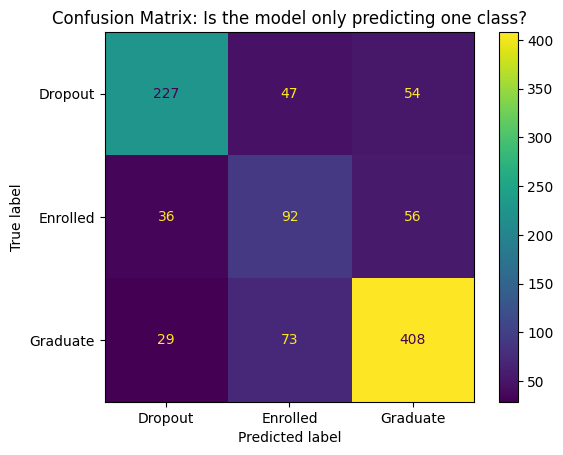

In [85]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate predictions for each data point using cross-validation
# y_pred = modelLogRes.predict(x_val_processed.to_numpy())

# Plot
cm = confusion_matrix(y_val_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix: Is the model only predicting one class?")
plt.show()

In [86]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train, y_train_encoded)

y_pred = model.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi Sklearn:", acc)


Akurasi Sklearn: 0.636986301369863


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## C. SVM

In [87]:
class SVM_Binary_cvxopt:
    def __init__(self, data_train, y_train, penalty=1.0, kernel='rbf'):
        self.data = np.asarray(data_train, dtype=float)
        self.y = np.asarray(y_train, dtype=float)
        self.C = penalty

        self.gamma = 1 / self.data.shape[1]

        self.kernel = self.rbf_kernel if kernel == 'rbf' else self.linear_kernel
        self.cache_kernel()
        self.eps = 1e-8

    def linear_kernel(self, x, z):
        return np.dot(x, z)

    def rbf_kernel(self, x, z):
        return np.exp(-self.gamma * np.linalg.norm(x - z)**2)

    def cache_kernel(self):
        n = len(self.data)
        K = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                K[i, j] = self.kernel(self.data[i], self.data[j])
        self.kernel_matriks = K

    def fit_binary(self):

        P = matrix(np.outer(self.y, self.y) * self.kernel_matriks)
        q = matrix(-1.0 * np.ones(len(self.data)))

        G = matrix(np.vstack((-np.eye(len(self.data)),
                              np.eye(len(self.data)))))
        h = matrix(np.hstack((np.zeros(len(self.data)),
                              np.ones(len(self.data)) * self.C)))

        A = matrix(self.y.reshape(1, -1))
        b = matrix(0.0)

        solution = solvers.qp(P, q, G, h, A, b)
        alphas = np.array(solution['x']).flatten()

        idx = alphas > self.eps
        self.support_alphas = alphas[idx]
        self.support_vectors = self.data[idx]
        self.support_labels = self.y[idx]

        b_list = []
        for i, xi in enumerate(self.support_vectors):
            k = np.array([self.kernel(xi, sv) for sv in self.support_vectors])
            b_i = self.support_labels[i] - np.sum(self.support_alphas * self.support_labels * k)
            b_list.append(b_i)

        self.b = np.mean(b_list)

        return alphas


    def predict(self, X_test):
        X_test = np.asarray(X_test, dtype=float)
        result = []

        for x in X_test:
            k = np.array([self.kernel(x, sv) for sv in self.support_vectors])
            fx = np.sum(self.support_alphas * self.support_labels * k) + self.b
            result.append(np.sign(fx))

        return np.array(result)


In [88]:
#Algoritma Optimasi SMO oleh JOHN PLATT
class SVM_Binary:
    def __init__(self, data_train: pd.DataFrame, y_train: pd.Series, penalty: float = 1.0, kernel: str = 'rbf') -> None:
        self.data = np.asarray(data_train, dtype=float)
        self.y = np.asarray(y_train, dtype=float)

        self.C = penalty
        self.max_passes = 5
        self.eps = 1e-8

        if kernel == 'rbf':
            self.gamma = 1 / self.data.shape[1]
            self.kernel = self.rbf_kernel
        elif kernel == 'linear':
            self.kernel = self.linear_kernel
        else:
            raise ValueError("Kernel tidak dikenal")

        self.b = 0.0
        self.alpha = np.zeros(len(self.data))
        self.E = -self.y.copy()
        self.cache_kernel()
        print("selesai caching kernel")

    def linear_kernel(self, x, z):
        return np.dot(x, z)

    def rbf_kernel(self, x, z):
        return np.exp(-self.gamma * np.linalg.norm(x - z)**2)

    def fxi(self, j):
        return np.sum(self.alpha * self.y * self.kernel_matriks[:, j]) + self.b

    def compute_error(self, k):
        return self.fxi(k) - self.y[k]

    def cache_kernel(self) -> None:
        n = len(self.data)
        kernel_matriks = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                kernel_matriks[i, j] = self.kernel(self.data[i], self.data[j])

        self.kernel_matriks = kernel_matriks

    def check_kkt(self, alpha_i, y_i, fxi):
        if alpha_i < 1e-3 and y_i * fxi >= 1 - 1e-3:
            return True
        if 1e-3 < alpha_i < self.C - 1e-3 and abs(y_i * fxi - 1) <= 1e-3:
            return True
        if alpha_i > self.C - 1e-3 and y_i * fxi <= 1 + 1e-3:
            return True

        return False

    def count_objective(self, i1: int, i2: int, alpha2_new):
        alpha1_old = self.alpha[i1]
        alpha2_old = self.alpha[i2]
        y1, y2 = self.y[i1], self.y[i2]

        alpha1_new = alpha1_old + y1 * y2 * (alpha2_old - alpha2_new)

        K11 = self.kernel_matriks[i1,i1]
        K22 = self.kernel_matriks[i2,i2]
        K12 = self.kernel_matriks[i1,i2]

        return (alpha1_new + alpha2_new
            - 0.5 * (
                alpha1_new * alpha1_new * y1 * y1 * K11 +
                alpha2_new * alpha2_new * y2 * y2 * K22 +
                2 * alpha1_new * alpha2_new * y1 * y2 * K12
            ))



    def take_step(self, i1: int, i2: int) -> bool:
        # i1 = candidate index, i2 = index being examined
        if i1 == i2:
            return False

        alpha1_old = self.alpha[i1]
        alpha2_old = self.alpha[i2]
        y1 = self.y[i1]
        y2 = self.y[i2]
        E1 = self.E[i1]
        E2 = self.E[i2]

        # compute L and H
        if y1 != y2:
            L = max(0.0, alpha2_old - alpha1_old)
            H = min(self.C, self.C + alpha2_old - alpha1_old)
        else:
            L = max(0.0, alpha1_old + alpha2_old - self.C)
            H = min(self.C, alpha1_old + alpha2_old)

        if L == H:
            return False

        K11 = self.kernel_matriks[i1, i1]
        K22 = self.kernel_matriks[i2, i2]
        K12 = self.kernel_matriks[i1, i2]

        eta = K11 + K22 - 2.0 * K12
        if eta <= 1e-12:
            #jika eta < 0, maka fungsi W(alpha) berubah jadi convex sehingga max seharusnya ada di rentang [L,H]
            obj_L = self.count_objective(i1, i2, L)
            obj_H = self.count_objective(i1, i2, H)

            if obj_L > obj_H:
                alpha2_new = L
            else:
                alpha2_new = H

            # jika selisih terlalu kecil gagal
            if abs(alpha2_new - alpha2_old) < self.eps:
                return False
        else:
            alpha2_new = alpha2_old + y2 * (E1 - E2) / eta

            if alpha2_new > H:
                alpha2_new = H
            elif alpha2_new < L:
                alpha2_new = L

            # jika selisih terlalu kecil gagal
            if abs(alpha2_new - alpha2_old) < self.eps:
                return False

        alpha1_new = alpha1_old + y1 * y2 * (alpha2_old - alpha2_new)

        b_old = self.b
        b1 = b_old - E1 - y1 * (alpha1_new - alpha1_old) * K11 - y2 * (alpha2_new - alpha2_old) * K12
        b2 = b_old - E2 - y1 * (alpha1_new - alpha1_old) * K12 - y2 * (alpha2_new - alpha2_old) * K22

        if 0.0 < alpha1_new < self.C:
            b_new = b1
        elif 0.0 < alpha2_new < self.C:
            b_new = b2
        else:
            b_new = 0.5 * (b1 + b2)

        self.alpha[i1] = alpha1_new
        self.alpha[i2] = alpha2_new
        self.b = b_new

        delta1 = alpha1_new - alpha1_old
        delta2 = alpha2_new - alpha2_old
        db = b_new - b_old
        contrib = (y1 * delta1) * self.kernel_matriks[i1, :] + (y2 * delta2) * self.kernel_matriks[i2, :] + db
        self.E = self.E + contrib


        return True

    def examine_example(self, i: int):
        n = len(self.data)
        yi = self.y[i]
        alpha2 = self.alpha[i]
        fxi = self.fxi(i)

        #optimasi hanya jika KKT dilanggar
        if not self.check_kkt(alpha2, yi, fxi):
            non_bounds = np.where((self.alpha > 0) & (self.alpha < self.C))[0]

            #heuristik 1
            if len(non_bounds) > 1:
                E2 = self.E[i]
                abs_diff = np.abs(E2 - self.E)
                abs_diff[i] = -1
                j = int(np.argmax(abs_diff))

                if j != i:
                    if self.take_step(j, i):
                        return True

            #heuristik 2
            if len(non_bounds) > 0:
                start = np.random.randint(0, len(non_bounds))
                order = list(non_bounds[start:]) + list(non_bounds[:start])
                for j in order:
                    if j == i:
                        continue
                    if self.take_step(j, i):
                        return True

            #heuristik 3
            start = np.random.randint(0, n)
            order = list(range(start, n)) + list(range(0, start))
            for j in order:
                if j == i:
                    continue
                if self.take_step(j, i):
                    return True


        return False

    def kernel_to_support(self, x):
        if not hasattr(self, "support_vectors") or len(self.support_vectors) == 0:
            return np.array([], dtype=float)
        return np.array([self.kernel(x, sv) for sv in self.support_vectors])


    def fit_binary(self):
        num_change : int = 0;
        passes : int= 0
        examine_all : bool = True

        while(passes < self.max_passes):
            num_change = 0
            if(examine_all):
                for i in range(len(self.data)):
                    if(self.examine_example(i)):
                        num_change += 1
            else:
                non_bounds = np.where((self.alpha > 0) & (self.alpha < self.C))[0]
                for i in non_bounds:
                    if(self.examine_example(i)):
                        num_change += 1

            if(examine_all):
                examine_all = False
            elif(num_change == 0):
                examine_all = True

            if num_change == 0:
                passes += 1
            else:
                passes = 0

        supp_idx_vector = np.where(self.alpha > self.eps)[0]
        self.support_labels = self.y[supp_idx_vector]
        self.support_alphas = self.alpha[supp_idx_vector]
        self.support_vectors = self.data[supp_idx_vector]

    def decision_function(self, X ):
        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(1, -1)

        size_X = X.shape[0]
        fx = np.empty(size_X, dtype=float)

        if not hasattr(self, "support_vectors") or len(self.support_vectors) == 0:
            fx[:] = self.b
            return fx

        for i in range(size_X):
            distance_arr = self.kernel_to_support(X[i])
            fx[i] = np.sum(self.support_alphas * self.support_labels * distance_arr) + self.b

        return fx


    def predict(self, X_predict):
        return np.where(self.decision_function(X_predict) >= 0, 1, -1)




In [89]:
import pickle

class SVM:
    def __init__(self, penalty: float = 1.0, kernel: str = 'rbf', smo =True) -> None:
        self.models = [] #berisi instance dari SVM_binary

        self.C = penalty
        self.kernel = kernel
        self.smo =smo

    def filter_data(self, labels1, labels2):
        filtered_data = self.raw_data[(self.raw_y == labels1) | (self.raw_y == labels2)].copy()
        filtered_y = self.raw_y[(self.raw_y == labels1) | (self.raw_y == labels2)].copy()

        filtered_y[filtered_y == labels1] = 1
        filtered_y[filtered_y == labels2] = -1

        print('Ini len raw ' + str(len(filtered_data)))
        print('Ini len y ' + str(len(filtered_y)))

        return filtered_data, filtered_y


    def fit(self, data_train: pd.DataFrame, y_train: pd.Series):
        self.raw_data = data_train
        self.raw_y = y_train
        unique_labels = np.unique(self.raw_y)
        count_unique = len(unique_labels)

        for i in range(count_unique):
            for j in range(i + 1, count_unique):
                label_a = unique_labels[i]
                label_b = unique_labels[j]

                filtered_data, filtered_y = self.filter_data(unique_labels[i], unique_labels[j])
                model= None
                if self.smo:
                    model = SVM_Binary(filtered_data, filtered_y, self.C, self.kernel)
                else:
                    model = SVM_Binary_cvxopt(filtered_data, filtered_y, self.C, self.kernel)
                model.fit_binary()

                self.models.append([label_a, label_b, model])

    def predict(self, X_predict):
        X_arr = np.asarray(X_predict, dtype=float)
        if X_arr.ndim == 1:
            X_arr = X_arr.reshape(1, -1)

        predictions = []
        for i in range(len(X_arr)):
            x = X_arr[i]
            voting = {} #berisi {key:count}

            for (label_a, label_b, svm_model) in self.models:
                pred = svm_model.predict([x])[0]
                if pred == 1:
                    key = label_a
                else:
                    key = label_b

                voting[key] = voting.get(key, 0) + 1

            max_vote = max(voting.values())
            candidates = [label for label, v in voting.items() if v == max_vote]
            final_label = min(candidates)
            predictions.append(final_label)

        return predictions

    def save_model(self, filepath: str):
        for _, _, model in self.models:
            if hasattr(model, "E"):
                del model.E
            if hasattr(model, "kernel_matriks"):
                del model.kernel_matriks

        if hasattr(self, "raw_data"):
            self.raw_data = None
        if hasattr(self, "raw_y"):
            self.raw_y = None

        try:
            with open(filepath, "wb") as f:
                pickle.dump(self, f)
            print(f"Model berhasil disimpan ke {filepath}")
        except Exception as e:
            print(f"Gagal menyimpan model: {e}")

    @staticmethod
    def load_model(filepath: str) -> "SVM":
        try:
            with open(filepath, "rb") as f:
                obj = pickle.load(f)

            if not isinstance(obj, SVM):
                raise TypeError("File pickle tidak berisi objek SVM")

            print(f"Model berhasil dimuat dari {filepath}")
            print(f"Jumlah sub-model (One-vs-One) yang dimuat: {len(obj.models)}")
            return obj

        except Exception as e:
            print(f"Gagal memuat model: {e}")
            raise

### SVM cvxopt

In [90]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

model_pipeline_svm = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)),
    ('model', SVM(smo=False))
])


le = LabelEncoder()


y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

model_pipeline_svm.fit(x_train, y_train_encoded)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

y_pred = model_pipeline_svm.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi SVM:", acc)

# Save Pipeline
filename = 'svm_cvxopt_pipeline.pkl'

with open(filename, 'wb') as file:
    pickle.dump(model_pipeline_svm, file)

print(f"SVM Pipeline saved successfully to {filename}")

Ini len raw 2072
Ini len y 2072
     pcost       dcost       gap    pres   dres
 0:  1.4002e-14 -2.0720e+03  8e+03  1e+00  5e-15
 1:  1.4329e-15 -5.3755e+02  6e+02  1e-02  4e-15
 2:  3.7587e-16 -5.4278e+00  6e+00  1e-04  1e-15
 3:  3.8224e-18 -5.4279e-02  6e-02  1e-06  5e-16
 4:  3.8214e-20 -5.4279e-04  6e-04  1e-08  6e-16
 5:  3.8214e-22 -5.4279e-06  6e-06  1e-10  4e-16
 6:  3.8214e-24 -5.4279e-08  6e-08  1e-12  3e-16
Optimal solution found.
Ini len raw 2072
Ini len y 2072


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


     pcost       dcost       gap    pres   dres
 0: -8.6869e+02 -5.3455e+03  3e+04  3e+00  2e-13
 1: -5.5201e+02 -3.4136e+03  4e+03  2e-01  2e-13
 2: -5.5591e+02 -1.0596e+03  6e+02  2e-02  1e-13
 3: -6.0400e+02 -7.9649e+02  2e+02  7e-03  1e-13
 4: -6.2133e+02 -7.2349e+02  1e+02  3e-03  1e-13
 5: -6.2737e+02 -6.9985e+02  7e+01  1e-03  1e-13
 6: -6.3405e+02 -6.7664e+02  4e+01  6e-04  1e-13
 7: -6.3662e+02 -6.6846e+02  3e+01  4e-04  1e-13
 8: -6.3984e+02 -6.5861e+02  2e+01  2e-04  1e-13
 9: -6.4286e+02 -6.5016e+02  7e+00  4e-05  2e-13
10: -6.4418e+02 -6.4712e+02  3e+00  1e-05  1e-13
11: -6.4485e+02 -6.4562e+02  8e-01  1e-06  2e-13
12: -6.4503e+02 -6.4528e+02  2e-01  3e-07  1e-13
13: -6.4511e+02 -6.4515e+02  3e-02  2e-08  1e-13
14: -6.4512e+02 -6.4513e+02  4e-03  2e-09  1e-13
15: -6.4513e+02 -6.4513e+02  1e-04  5e-11  1e-13
Optimal solution found.
Ini len raw 2072
Ini len y 2072
     pcost       dcost       gap    pres   dres
 0: -1.3483e+03 -5.3687e+03  2e+04  3e+00  3e-13
 1: -9.2229e+02

/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(



Akurasi SVM: 0.5205479452054794
SVM Pipeline saved successfully to svm_cvxopt_pipeline.pkl


In [91]:
# Cara Load Pipeline
with open('svm_cvxopt_pipeline.pkl', 'rb') as file:
    loaded_svm_pipeline_cvxopt = pickle.load(file)

print("SVM Pipeline loaded successfully!")
y_pred_svm = loaded_svm_pipeline_cvxopt.predict(df_test)

acc = accuracy_score(y_val_encoded, y_pred)
print("\nAkurasi SVM (cvxopt):", acc)

SVM Pipeline loaded successfully!

Akurasi SVM (cvxopt): 0.5205479452054794


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


### SVM SMO John Platt

In [92]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

model_pipeline_svm = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)),
    ('model', SVM())
])


le = LabelEncoder()


y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

model_pipeline_svm.fit(x_train, y_train_encoded)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

y_pred = model_pipeline_svm.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi SVM (SMO John Platt):", acc)

# Save Pipeline
filename = 'svm_smo_pipeline.pkl'

with open(filename, 'wb') as file:
    pickle.dump(model_pipeline_svm, file)

print(f"SVM Pipeline saved successfully to {filename}")

Ini len raw 2072
Ini len y 2072
selesai caching kernel
Ini len raw 2072
Ini len y 2072
selesai caching kernel
Ini len raw 2072
Ini len y 2072
selesai caching kernel
Preprocessing Complete!
Processed Train Shape: (2074, 37)


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(



Akurasi SVM (SMO John Platt): 0.6800391389432485
SVM Pipeline saved successfully to svm_smo_pipeline.pkl


In [93]:
# Cara Load Pipeline
with open('svm_smo_pipeline.pkl', 'rb') as file:
    loaded_svm_pipeline_smo = pickle.load(file)

print("SVM Pipeline loaded successfully!")
y_pred_svm = loaded_svm_pipeline_smo.predict(df_test)

acc = accuracy_score(y_val_encoded, y_pred)
print("\nAkurasi SVM (smo/John Platt):", acc)

SVM Pipeline loaded successfully!

Akurasi SVM (smo/John Platt): 0.6800391389432485


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


In [94]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

model_pipeline = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale')  )
])


le = LabelEncoder()


y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

model_pipeline.fit(x_train, y_train_encoded)

print("Preprocessing Complete!")
print(f"Processed Train Shape: {x_train.shape}")

y_pred = model_pipeline.predict(x_val)
acc = accuracy_score(y_val_encoded, y_pred)

print("\nAkurasi SVM SCIKIT:", acc)

Preprocessing Complete!
Processed Train Shape: (2074, 37)

Akurasi SVM SCIKIT: 0.6731898238747553


## D. Submission

In [95]:
student_id = df_test['Student_ID'].to_numpy()


DTL

In [96]:
original_y_train = df['Target']
original_x_train = df.drop('Target', axis=1)
student_id = df_test['Student_ID']


model_pipeline_dtl = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)), # Select top 30 strongest features
    ('model', DecisionTreeLearning(max_depth=5, min_samples_split=2, min_samples_leaf=5))
])



y_train_encoded = le.fit_transform(original_y_train)

model_pipeline_dtl.fit(original_x_train, y_train_encoded)
y_pred_test_processed_dtl = model_pipeline_dtl.predict(df_test)
y_pred_decoded_dtl = le.inverse_transform(y_pred_test_processed_dtl.astype(int))

df_to_submit = pd.DataFrame({
    'Student_ID':student_id,
    'Target': y_pred_decoded_dtl
})
df_to_submit.to_csv('submission_DTL_SCRATCH.csv', index=False)


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


Logistic Regression

In [97]:
original_y_train = df['Target']
original_x_train = df.drop('Target', axis=1)
student_id = df_test['Student_ID']

model_pipeline_logres = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    # ('selection', SelectKBest(score_func=f_classif, k=30)), # Select top 30 strongest features

    ('model', LogisticRegressionOVO(lr=0.3, epochs=100, batch_size=32))
])

y_train_encoded = le.fit_transform(original_y_train)
model_pipeline_logres.fit(original_x_train, y_train_encoded)

y_pred_test_processed_logres = model_pipeline_logres.predict(df_test)
y_pred_decoded_logres = le.inverse_transform(y_pred_test_processed_logres)

df_to_submit = pd.DataFrame({
    'Student_ID':student_id,
    'Target': y_pred_decoded_logres
})
df_to_submit.to_csv('submission_Logres_SCRATCH.csv', index=False)


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(


SVM

In [98]:
original_x_train = df.drop(columns = ['Target']).copy()
original_y_train = df['Target'].copy()
student_id = df_test['Student_ID']


model_pipeline_svm = ImbPipeline([
    ('feat_eng', FunctionTransformer(engineering_logic, validate=False)),
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selection', SelectKBest(score_func=f_classif, k=5)),
    ('model', SVM())
])


le = LabelEncoder()


y_train_encoded = le.fit_transform(original_y_train)
model_pipeline_svm.fit(original_x_train, y_train_encoded)

y_pred_test_processed_svm = model_pipeline_svm.predict(df_test)
y_pred_decoded_svm = le.inverse_transform(y_pred_test_processed_svm)

df_to_submit = pd.DataFrame({
    'Student_ID':student_id,
    'Target': y_pred_decoded_svm
})
df_to_submit.to_csv('submission_SVM_SCRATCH.csv', index=False)



Ini len raw 3092
Ini len y 3092
selesai caching kernel
Ini len raw 3092
Ini len y 3092
selesai caching kernel
Ini len raw 3092
Ini len y 3092
selesai caching kernel


/home/ihaidar/Projects/Tubes_AI_2/venv/lib/python3.12/site-packages/imblearn/pipeline.py:65: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 0.15 instead of the current warning.
  warnings.warn(
